# Convergent Validity Analysis: Theoretical Background

This notebook examines **convergent validity** for the DEEP developmental subscales by testing whether they are statistically related to external variables that theory suggests should be related to child development.

The core statistical workflow is:

1. Prepare one analysis dataset by merging child-level convergent variables with DEEP subscale scores.
2. Estimate **Pearson correlations** between each convergent variable and each DEEP subscale.
3. Attach **p-values**, **95% confidence intervals**, and **BH-FDR adjusted p-values** to each correlation.
4. Mark adjusted statistical evidence using significance symbols (`·`, `*`, `**`, `***`).
5. Visualize the pattern with heatmaps and export the results to CSV.

The documentation below explains the theory behind these concepts so the results can be interpreted correctly.


## Data Structure and Purpose

Each row represents a child. The analysis keeps one record per child, then merges the convergent-validity variables with the DEEP results using `child_ids`.

The DEEP variables are treated as developmental outcome subscales:

- `fol`: Foundations of Learning
- `langCom`: Language Comprehension
- `eye_hand`: Eye-Hand Coordination
- `soc_per`: Social Perception
- `gross_mot`: Gross Motor

The convergent variables include family care, attachment, sleep, socioeconomic status, maternal mental health, parent-child relationship measures, education, biological/nutritional indicators, risk measures, and anthropometry.

The statistical question is not simply "which variables are significant?" but rather: **Do the DEEP subscales correlate with external measures in theoretically expected directions?** Evidence for such expected associations supports convergent validity.


In [8]:
import pandas as pd
data = pd.read_csv("bhisma_data.csv")

convergent_cols = [
    "cortisol",
    "cpas",
    "bisq",
    "ses",
    "fci",
    "phq9.score",
    "mors.invasion",
    "mors.warmth",
    "cprs.closeness",
    "cprs.conflict",
    "anthro.waz",
    "anthro.haz",
    "anthro.wfl",
    "anthro.hcz",
    "pmp.daz",
    "maternal.edu",
    "paternal.edu",
    "maternal.muac",
    "rbs.bin.risk",
    "pci.int",
]

data = (
    data.rename(columns={"id": "child_ids"})
    .drop_duplicates(subset="child_ids")
    .assign(
        country=lambda df: df["country"].astype(str),
        child_ids=lambda df: df["child_ids"].astype(str) + "-BL",
    )
    [["child_ids", "country"] + convergent_cols]
)

data.head()


,child_ids,country,cortisol,cpas,bisq,ses,fci,phq9.score,mors.invasion,mors.warmth,...,anthro.waz,anthro.haz,anthro.wfl,anthro.hcz,pmp.daz,maternal.edu,paternal.edu,maternal.muac,rbs.bin.risk,pci.int
0,IN-0003-BL,IN,NaN,0.829047,NaN,-1.100828,0.081612,1.503747,NaN,NaN,...,1.035191,1.846310,-0.275999,0.249022,-0.676677,-1.513419,-1.214618,-1.809783,0.0,NaN
1,IN-0006-BL,IN,NaN,0.431599,NaN,0.689174,0.457766,0.050641,NaN,NaN,...,0.305472,-0.797824,1.221073,-0.811038,-1.801249,0.239936,0.054454,-0.421868,0.0,NaN
2,IN-0007-BL,IN,NaN,0.101850,NaN,-0.745042,1.507111,1.261563,1.776966,0.185820,...,-1.200150,-1.037449,-1.010588,-0.414668,NaN,1.993290,0.054454,-0.678890,0.0,NaN
3,IN-0011-BL,IN,NaN,1.749237,NaN,-0.429187,0.346437,0.535010,NaN,NaN,...,NaN,NaN,NaN,NaN,0.490089,0.239936,-1.214618,-0.267656,0.0,NaN
4,IN-0012-BL,IN,NaN,0.653623,NaN,-0.533899,-2.258632,2.714669,2.333645,-0.338556,...,-0.950752,0.639923,-1.763773,-0.313271,NaN,0.239936,0.054454,0.323493,0.0,NaN


# Convergent Validity: DEEP Age-Adjusted Latent Score

This notebook examines **convergent validity** for the DEEP latent total score (`total_DEEP_daz`) — the age-adjusted (GAMLSS-normalised) version of the DEEP IRT–VAE total ability. It tests whether the score is statistically associated with external variables that theory predicts should relate to child development.

## Context

The DEEP total latent score is age-normalised using GAMLSS to produce `total_DEEP_daz`, removing the chronological age trend and isolating individual developmental variation. DEEP is designed for children aged 3–6, so the convergent analysis is conducted on that age band.

The convergent variables are grouped into:
- **Expected positive**: attachment security (CPAS), family care (FCI), parent-child closeness (CPRS), SES, maternal/paternal education, maternal nutrition (MUAC), parent-child interaction (PCI), HAZ.
- **Expected negative**: sleep problems (BISQ), maternal depression (PHQ-9), parent-child conflict (CPRS conflict), risk score (RBS).

## Statistical approach

1. **Pearson r** between `total_DEEP_daz` and each convergent variable.
2. **95% confidence intervals** via Fisher z-transformation.
3. **BH-FDR correction** across all tests in each analysis family.
4. Country-stratified analyses (India, Malawi) and a pooled combined analysis.

See `convergent_analysis_of_GMDS_predicted_using_DEEP.ipynb` for a detailed explanation of the statistical methods.

## Convergent Validity

**Convergent validity** is a form of construct validity. A measure shows convergent validity when it is associated with other measures that should theoretically be related to the same or similar construct.

In this notebook, DEEP subscales are compared with external developmental, family, psychosocial, biological, and risk indicators. For example:

- Measures expected to reflect supportive environments or better developmental conditions are placed in the **expected positive** group.
- Measures expected to reflect stress, risk, conflict, or developmental burden are placed in the **expected negative** group.
- Anthropometric indicators are analysed separately because they are biological growth measures and have a different conceptual interpretation from psychosocial or caregiving variables.

A result supports convergent validity when the association is both **in the expected direction** and strong enough to be meaningful. Statistical significance alone is not enough; the direction, size, confidence interval, and theoretical plausibility all matter.


## Pearson Correlation (`r`)

The main statistic in the notebook is the **Pearson product-moment correlation coefficient**, usually written as `r`.

Pearson `r` measures the strength and direction of the linear association between two numeric variables:

\[
r = \frac{\operatorname{cov}(X,Y)}{s_X s_Y}
\]

where `cov(X,Y)` is the covariance between two variables and `s_X` and `s_Y` are their standard deviations.

Interpretation:

- `r = +1`: perfect positive linear relationship
- `r = 0`: no linear relationship
- `r = -1`: perfect negative linear relationship
- Positive `r`: higher values of one variable tend to go with higher values of the other
- Negative `r`: higher values of one variable tend to go with lower values of the other

A rough descriptive guide is:

- `|r| ≈ .10`: small association
- `|r| ≈ .30`: moderate association
- `|r| ≈ .50` or larger: large association

These are only rules of thumb. In child-development and public-health data, even small correlations can be meaningful when the construct is complex, the sample is large, or the variable is difficult to measure.

Important assumptions and cautions:

- Pearson correlation captures **linear** association, not curved or threshold patterns.
- It is sensitive to outliers.
- The p-value and confidence interval assume independent observations and are most reliable when the paired variables are approximately bivariate normal.
- Correlation does **not** imply causation.


## P-values and Hypothesis Testing

For every pair of variables, the notebook tests the null hypothesis:

\[
H_0: \rho = 0
\]

where `ρ` is the true population correlation. The alternative hypothesis is that the true correlation is not zero.

The **p-value** answers this question:

> If the true population correlation were zero, how surprising would a correlation at least this extreme be in a sample of this size?

Smaller p-values indicate stronger evidence against the null hypothesis. However, a p-value does **not** tell us the probability that the null hypothesis is true, and it does **not** tell us whether the association is practically important.

The raw p-value is affected by sample size. With a large sample, very small correlations can become statistically significant. With a small sample, even meaningful correlations can fail to reach significance. That is why the notebook reports `r`, confidence intervals, and adjusted p-values together.


## 95% Confidence Intervals

A **95% confidence interval** gives a range of plausible values for the true population correlation.

In this notebook, the confidence interval is produced from the Pearson correlation result. Conceptually, this uses Fisher's `z` transformation:

\[
z = \operatorname{atanh}(r)
\]

with approximate standard error:

\[
SE_z = \frac{1}{\sqrt{n - 3}}
\]

A 95% interval is formed on the `z` scale:

\[
z \pm 1.96 \times SE_z
\]

and then transformed back to the correlation scale.

How to read the interval:

- A narrow interval means the correlation estimate is precise.
- A wide interval means there is more uncertainty.
- If the interval includes `0`, the data are compatible with no linear association at the 95% confidence level.
- If the entire interval is positive or entirely negative, the direction of the association is more stable.

Confidence intervals are often more informative than stars because they show both the estimated effect and the uncertainty around it.


## Multiple Testing and BH-FDR Correction

The notebook computes many correlations: each convergent variable is correlated with each DEEP subscale. When many hypothesis tests are performed, some small p-values can appear by chance even if there are no real associations.

To reduce this problem, the notebook applies the **Benjamini-Hochberg False Discovery Rate correction**, often abbreviated as **BH-FDR**.

The false discovery rate is the expected proportion of statistically significant findings that are false positives. BH-FDR is less conservative than Bonferroni correction, so it is useful when testing many related hypotheses and when the goal is to identify a pattern of plausible associations rather than protect against any single false positive at all costs.

In this notebook:

- Raw p-values are computed for all correlations in a result matrix.
- Those p-values are flattened into one family of tests.
- BH-FDR adjusted p-values are calculated.
- The adjusted p-values are reshaped back into the same table/heatmap structure.

The adjustment is done separately for each call to the correlation table function. Therefore, the India, Malawi, combined, and anthropometric analyses each have their own correction family.


## Significance Symbols: The "Stars Thing"

The notebook converts the **BH-FDR adjusted p-value** into a compact symbol:

- `***` means `p_adj < .001`
- `**` means `p_adj < .01`
- `*` means `p_adj < .05`
- `·` means `p_adj < .10`
- blank means `p_adj >= .10` or the value could not be calculated

These symbols are only shorthand for adjusted statistical evidence. They should not be read as effect sizes.

For example, a small correlation can receive stars in a large sample, while a larger correlation may receive no stars in a smaller or noisier sample. Always interpret the stars together with:

- the sign of `r`
- the magnitude of `r`
- the 95% confidence interval
- the theoretical expected direction
- the number of valid observations


## Missing Data, Pairwise Sample Size, and Minimum `n`

For each correlation, the notebook uses only rows where both variables in that pair are non-missing. This is called **pairwise complete-case analysis**.

Because different variables can have different missingness patterns, the effective sample size `n` can differ from one correlation to another. The notebook stores this `n` in the exported results.

The function only computes a correlation when at least `min_n = 8` paired observations are available. If fewer than 8 paired observations are available, the result is left missing. This avoids reporting extremely unstable correlations based on very small samples.

Pairwise deletion is practical, but it assumes the available pairs are reasonably representative. If missingness is systematic, correlations can be biased.


In [9]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Load DEEP & merge ────────────────────────────────────────────────────────
deep = pd.read_csv("total_DEEP_gamlss_results.csv")
deep = deep.drop_duplicates(subset="child_ids").assign(child_ids=lambda df: df["child_ids"].astype(str))
assert deep["child_ids"].shape[0] < 4000, "Unexpectedly many rows in DEEP data after deduplication"
deep_subscales = ["total_DEEP_daz"]

merged = data.merge(deep[["child_ids"] + deep_subscales], on="child_ids", how="inner")
merged["country_group"] = merged["child_ids"].str[:2]

india  = merged[merged["country_group"] == "IN"].copy()
malawi = merged[merged["country_group"] == "MW"].copy()

print(f"Children after merge:  {len(merged):>4}  total")
print(f"  India  (IN):         {len(india):>4}")
print(f"  Malawi (MW):         {len(malawi):>4}")

# ── Readable labels ───────────────────────────────────────────────────────────
convergent_labels = {
    "cortisol":       "Cortisol",
    "cpas":           "CPAS (Attachment)",
    "bisq":           "BISQ (Sleep)",
    "ses":            "SES",
    "fci":            "FCI (Family Care)",
    "phq9.score":     "PHQ-9 (Dep. Sx)",
    "mors.invasion":  "MORS Invasion",
    "mors.warmth":    "MORS Warmth",
    "cprs.closeness": "CPRS Closeness",
    "cprs.conflict":  "CPRS Conflict",
    "anthro.waz":     "WAZ (Wt-for-age)",
    "anthro.haz":     "HAZ (Ht-for-age)",
    "anthro.wfl":     "WFL (Wt-for-len.)",
    "anthro.hcz":     "HCZ (Head Circumf.)",
    "pmp.daz":        "PMP DAZ",
    "maternal.edu":   "Maternal Education",
    "paternal.edu":   "Paternal Education",
    "maternal.muac":  "Maternal MUAC",
    "rbs.bin.risk":   "RBS Risk",
    "pci.int":        "PCI Interaction",
}

deep_labels = {
    "fol":       "Foundations of Learning",
    "langCom":   "Lang. Comp.",
    "eye_hand":  "Eye–Hand",
    "soc_per":   "Soc. Percep.",
    "gross_mot": "Gross Motor",
}

# ── Variable ordering ─────────────────────────────────────────────────────────
anthro_cols = ["anthro.haz"]

pos_convergent_cols = [
    "cpas",           # attachment security → better development
    "fci",            # family care/stimulation → better development
    "cprs.closeness", # parent-child closeness → better development
    "ses",            # socioeconomic resources → better development
    "maternal.edu",   # maternal education → better development
    "paternal.edu",   # paternal education → better development
    "maternal.muac",  # maternal nutrition → better child development
    "pci.int",        # parent-child interaction quality → better development
    "anthro.haz",     # height-for-age → better development
]
neg_convergent_cols = [
    "bisq",           # sleep problems → worse development
    "phq9.score",     # maternal depression → worse development
    "cprs.conflict",  # parent-child conflict → worse development
    "rbs.bin.risk",   # risk score → worse development
]
convergent_cols_ordered = pos_convergent_cols + neg_convergent_cols
N_POS = len(pos_convergent_cols)

# ── BH-FDR correction ────────────────────────────────────────────────────────
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out   = np.full_like(pvals, np.nan)
    valid = ~np.isnan(pvals)
    idx   = np.where(valid)[0]
    m     = idx.size
    if m == 0:
        return out
    p_sub  = pvals[idx]
    order  = np.argsort(p_sub)
    ranked = np.empty(m); ranked[order] = np.arange(1, m + 1)
    adj    = p_sub * m / ranked
    adj_sorted = adj[order]
    for i in range(m - 2, -1, -1):
        adj_sorted[i] = min(adj_sorted[i], adj_sorted[i + 1])
    adj[order] = adj_sorted
    out[idx] = np.clip(adj, 0, 1)
    return out

# ── Pearson r + 95% CI (Fisher z) + BH-FDR ──────────────────────────────────
def pearson_table(df, row_vars, col_vars, min_n=8):
    r_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    p_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    lo_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    hi_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    n_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    for i, rv in enumerate(row_vars):
        for j, cv in enumerate(col_vars):
            tmp = df[[rv, cv]].dropna()
            n   = len(tmp)
            n_mat[i, j] = n
            if n >= min_n:
                res = stats.pearsonr(tmp[rv], tmp[cv])
                r_mat[i, j]  = res.statistic
                p_mat[i, j]  = res.pvalue
                ci = res.confidence_interval(confidence_level=0.95)
                lo_mat[i, j] = ci.low
                hi_mat[i, j] = ci.high
    pa_flat = bh_fdr(p_mat.flatten())
    pa_mat  = pa_flat.reshape(p_mat.shape)
    kw = dict(index=row_vars, columns=col_vars)
    return (
        pd.DataFrame(r_mat,  **kw), pd.DataFrame(p_mat,  **kw),
        pd.DataFrame(pa_mat, **kw), pd.DataFrame(lo_mat, **kw),
        pd.DataFrame(hi_mat, **kw), pd.DataFrame(n_mat,  **kw),
    )

# ── Significance stars ────────────────────────────────────────────────────────
def stars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    if p < 0.10:   return "·"
    return ""

# ── Formatted table: r* [lo, hi] ─────────────────────────────────────────────
def make_display_table(r_df, pa_df, lo_df, hi_df):
    rows = [convergent_labels.get(r, r) for r in r_df.index]
    cols = [deep_labels.get(c, c)       for c in r_df.columns]
    out  = pd.DataFrame(index=rows, columns=cols)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            r  = r_df.iloc[i, j];  p  = pa_df.iloc[i, j]
            lo = lo_df.iloc[i, j]; hi = hi_df.iloc[i, j]
            if np.isnan(r):
                out.iloc[i, j] = "—"
            else:
                out.iloc[i, j] = f"{r:+.2f}{stars(p):3} [{lo:+.2f}, {hi:+.2f}]"
    return out

# ── Heatmap — r, CI, and N shown inside cells ────────────────────────────────
def draw_heatmap(r_df, pa_df, lo_df, hi_df, n_df, title, ax, show_separator=True):
    r_plot = r_df.copy().astype(float)
    r_plot.index   = [convergent_labels.get(r, r) for r in r_df.index]
    r_plot.columns = [deep_labels.get(c, c)       for c in r_df.columns]

    annot = pd.DataFrame("", index=r_plot.index, columns=r_plot.columns)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            val   = r_df.iloc[i, j];  p    = pa_df.iloc[i, j]
            lo    = lo_df.iloc[i, j]; hi   = hi_df.iloc[i, j]
            n_val = n_df.iloc[i, j]
            rl = convergent_labels.get(rv, rv)
            cl = deep_labels.get(cv, cv)
            if not np.isnan(val):
                s     = stars(p)
                line1 = f"{val:+.2f}{s}"
                line2 = f"[{lo:+.2f},{hi:+.2f}]" if not np.isnan(lo) else ""
                line3 = f"n={int(n_val)}" if not np.isnan(n_val) else ""
                annot.loc[rl, cl] = "\n".join(l for l in [line1, line2, line3] if l)

    sns.heatmap(
        r_plot, ax=ax,
        annot=annot, fmt="",
        center=0, vmin=-1, vmax=1,
        cmap="RdBu_r",
        linewidths=0.5, linecolor="#e0e0e0",
        cbar_kws={"shrink": 0.55, "label": "Pearson r"},
        annot_kws={"size": 10},
    )

    if show_separator:
        n_rows = len(r_df)
        ax.hlines(N_POS, xmin=0, xmax=len(r_df.columns),
                  colors="#111", linewidths=2.5, linestyles="--")
        blend = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
        # ax.text(-0.01, N_POS / 2.0,
        #         "Expected\n(+)", ha="right", va="center",
        #         fontsize=7.5, color="#444", style="italic",
        #         transform=blend, clip_on=False)
        # ax.text(-0.01, N_POS + (n_rows - N_POS) / 2.0,
        #         "Expected\n(−)", ha="right", va="center",
        #         fontsize=7.5, color="#444", style="italic",
        #         transform=blend, clip_on=False)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("DEEP Subscale", fontsize=10, labelpad=6)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)


Children after merge:  1979  total
  India  (IN):          993
  Malawi (MW):          986


## Reading the Tables and Heatmaps

Each table/heatmap cell represents one correlation between one convergent variable and one DEEP subscale.

The displayed format is:

```text
r + significance symbol [95% CI lower, 95% CI upper]
```

For example:

```text
+0.23* [+0.10, +0.35]
```

means the estimated Pearson correlation is `+0.23`, the BH-FDR adjusted p-value is below `.05`, and the 95% confidence interval runs from `+0.10` to `+0.35`.

Heatmap colors represent the sign and magnitude of Pearson `r`:

- Red cells: positive correlations
- Blue cells: negative correlations
- Stronger color: larger absolute correlation
- Near-white cells: correlations near zero

The horizontal separator divides variables expected to correlate positively with DEEP scores from variables expected to correlate negatively with DEEP scores. A finding is most supportive of convergent validity when the sign of the correlation matches the expected direction and the confidence interval suggests a reasonably stable association.


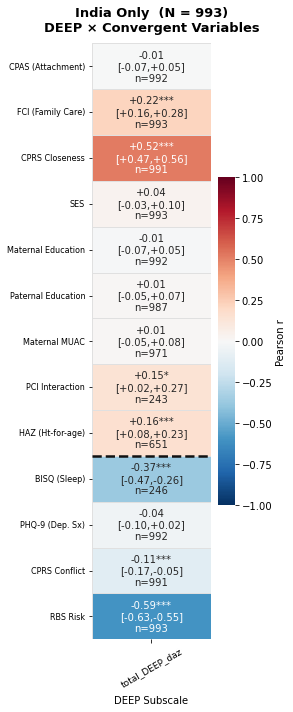


── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,total_DEEP_daz
CPAS (Attachment),"-0.01 [-0.07, +0.05]"
FCI (Family Care),"+0.22*** [+0.16, +0.28]"
CPRS Closeness,"+0.52*** [+0.47, +0.56]"
SES,"+0.04 [-0.03, +0.10]"
Maternal Education,"-0.01 [-0.07, +0.05]"
Paternal Education,"+0.01 [-0.05, +0.07]"
Maternal MUAC,"+0.01 [-0.05, +0.08]"
PCI Interaction,"+0.15* [+0.02, +0.27]"
HAZ (Ht-for-age),"+0.16*** [+0.08, +0.23]"
BISQ (Sleep),"-0.37*** [-0.47, -0.26]"



────────────────────────────────────────────────────────────
  India — Anthropometric Variables
────────────────────────────────────────────────────────────


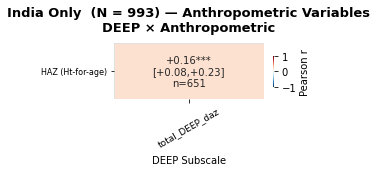


── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,total_DEEP_daz
HAZ (Ht-for-age),"+0.16*** [+0.08, +0.23]"


In [10]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 1 — INDIA ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_in, p_in, pa_in, lo_in, hi_in, n_in = pearson_table(india, convergent_cols_ordered, deep_subscales)

fig, ax = plt.subplots(figsize=(4, 10))
draw_heatmap(r_in, pa_in, lo_in, hi_in, n_in,
             f"India Only  (N = {len(india)})\nDEEP × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_india.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_in, pa_in, lo_in, hi_in))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  India — Anthropometric Variables")
print("─" * 60)
r_in_a, p_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a = pearson_table(india, anthro_cols, deep_subscales)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a,
             f"India Only  (N = {len(india)}) — Anthropometric Variables\nDEEP × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_india_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_in_a, pa_in_a, lo_in_a, hi_in_a))


## Country-Specific Analyses

The notebook first analyses India and Malawi separately. This is important because correlations can differ across contexts due to differences in measurement, social conditions, health environments, sample composition, or developmental risk profiles.

A country-specific correlation answers:

> Within this country, are children with higher values on the convergent variable also higher or lower on the DEEP subscale?

These analyses should not automatically be interpreted as proof that the countries differ from each other. To formally test whether a correlation is different across countries, one would need an interaction model or a direct comparison of correlations, such as a Fisher `r`-to-`z` comparison. The notebook's country-specific results are best read as stratified evidence patterns.


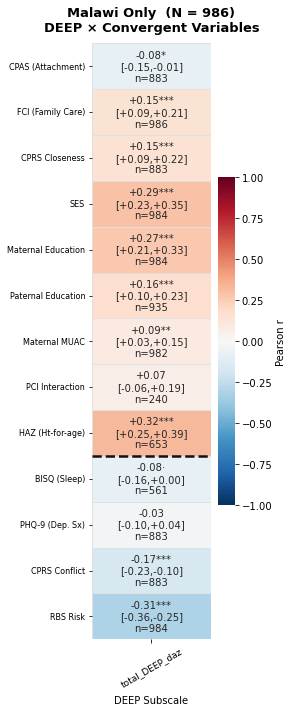


── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,total_DEEP_daz
CPAS (Attachment),"-0.08* [-0.15, -0.01]"
FCI (Family Care),"+0.15*** [+0.09, +0.21]"
CPRS Closeness,"+0.15*** [+0.09, +0.22]"
SES,"+0.29*** [+0.23, +0.35]"
Maternal Education,"+0.27*** [+0.21, +0.33]"
Paternal Education,"+0.16*** [+0.10, +0.23]"
Maternal MUAC,"+0.09** [+0.03, +0.15]"
PCI Interaction,"+0.07 [-0.06, +0.19]"
HAZ (Ht-for-age),"+0.32*** [+0.25, +0.39]"
BISQ (Sleep),"-0.08· [-0.16, +0.00]"



────────────────────────────────────────────────────────────
  Malawi — Anthropometric Variables
────────────────────────────────────────────────────────────


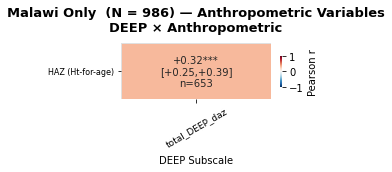


── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,total_DEEP_daz
HAZ (Ht-for-age),"+0.32*** [+0.25, +0.39]"


In [11]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 2 — MALAWI ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_mw, p_mw, pa_mw, lo_mw, hi_mw, n_mw = pearson_table(malawi, convergent_cols_ordered, deep_subscales)

fig, ax = plt.subplots(figsize=(4, 10))
draw_heatmap(r_mw, pa_mw, lo_mw, hi_mw, n_mw,
             f"Malawi Only  (N = {len(malawi)})\nDEEP × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_malawi.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_mw, pa_mw, lo_mw, hi_mw))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  Malawi — Anthropometric Variables")
print("─" * 60)
r_mw_a, p_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a = pearson_table(malawi, anthro_cols, deep_subscales)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a,
             f"Malawi Only  (N = {len(malawi)}) — Anthropometric Variables\nDEEP × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_malawi_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a))


## Combined Analysis

The combined analysis pools India and Malawi into one dataset. This increases sample size and can produce narrower confidence intervals, but it also averages across countries.

A combined correlation answers:

> Across the pooled sample, are higher values on the convergent variable associated with higher or lower DEEP scores?

The combined result is useful for identifying broad cross-sample patterns. However, it can hide country-specific differences or produce a pooled association that does not describe either country well. For this reason, the combined heatmap should be interpreted alongside the India-only and Malawi-only heatmaps.


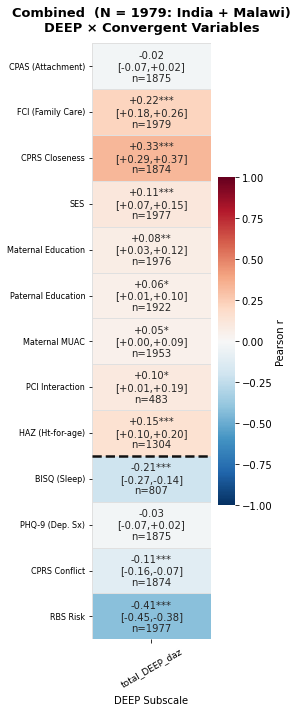


── Combined: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,total_DEEP_daz
CPAS (Attachment),"-0.02 [-0.07, +0.02]"
FCI (Family Care),"+0.22*** [+0.18, +0.26]"
CPRS Closeness,"+0.33*** [+0.29, +0.37]"
SES,"+0.11*** [+0.07, +0.15]"
Maternal Education,"+0.08** [+0.03, +0.12]"
Paternal Education,"+0.06* [+0.01, +0.10]"
Maternal MUAC,"+0.05* [+0.00, +0.09]"
PCI Interaction,"+0.10* [+0.01, +0.19]"
HAZ (Ht-for-age),"+0.15*** [+0.10, +0.20]"
BISQ (Sleep),"-0.21*** [-0.27, -0.14]"



────────────────────────────────────────────────────────────
  Combined — Anthropometric Variables
────────────────────────────────────────────────────────────


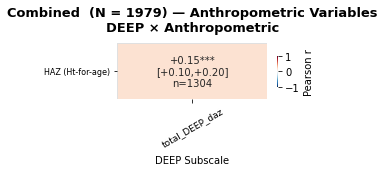


── Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,total_DEEP_daz
HAZ (Ht-for-age),"+0.15*** [+0.10, +0.20]"


In [12]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 3 — COMBINED (India + Malawi)
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_all, p_all, pa_all, lo_all, hi_all, n_all = pearson_table(merged, convergent_cols_ordered, deep_subscales)

fig, ax = plt.subplots(figsize=(4, 10))
draw_heatmap(r_all, pa_all, lo_all, hi_all, n_all,
             f"Combined  (N = {len(merged)}: India + Malawi)\nDEEP × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_combined.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Combined: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_all, pa_all, lo_all, hi_all))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  Combined — Anthropometric Variables")
print("─" * 60)
r_all_a, p_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a = pearson_table(merged, anthro_cols, deep_subscales)

fig, ax = plt.subplots(figsize=(4, 2.5))
draw_heatmap(r_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a,
             f"Combined  (N = {len(merged)}) — Anthropometric Variables\nDEEP × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_combined_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_all_a, pa_all_a, lo_all_a, hi_all_a))


## Why Anthropometric Variables Are Analysed Separately

Anthropometric variables such as WAZ, HAZ, WFL, and HCZ are standardized growth indicators. They are biologically meaningful, but they are conceptually different from psychosocial, family, mental-health, and caregiving measures.

Analysing them separately helps avoid mixing different theoretical families of variables in the same heatmap and correction family. It also makes the results easier to interpret because growth indicators may relate to developmental subscales through nutritional, biological, health, and environmental pathways rather than through the same mechanisms as family interaction or psychosocial risk measures.


## Summary Counts

The summary table counts, for each convergent variable, how many DEEP subscales have `p_adj < .05`.

This is a compact way to see which convergent variables show the broadest pattern of statistically supported associations. However, it should be treated as a screening summary, not as a complete interpretation.

The count does not show:

- whether the correlations are positive or negative
- how large the correlations are
- how wide the confidence intervals are
- whether the association matches the expected theoretical direction
- whether one strong association is more meaningful than several tiny ones

The detailed heatmaps and tables should be used for substantive interpretation.


  Convergent Variable Summary  (# DEEP subscales with p_adj < .05)


,India (sig. subscales),Malawi (sig. subscales),Combined (sig. subscales)
FCI (Family Care),1,1,1
SES,0,1,1
CPRS Closeness,1,1,1
Maternal Education,0,1,1
Paternal Education,0,1,1
BISQ (Sleep),1,0,1
Maternal MUAC,0,1,1
PCI Interaction,1,0,1
HAZ (Ht-for-age),1,1,1
RBS Risk,1,1,1


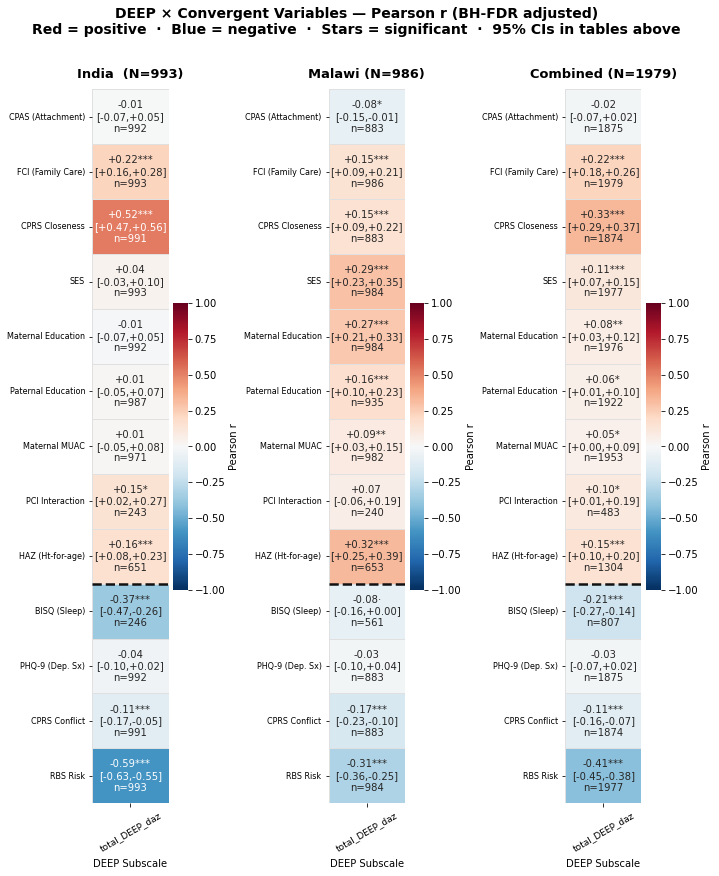

In [13]:

# ═══════════════════════════════════════════════════════════
#  SUMMARY — significant hits per convergent variable
# ═══════════════════════════════════════════════════════════

def sig_count(pa_df, threshold=0.05):
    """Count number of DEEP subscales with FDR-adjusted p < threshold."""
    return (pa_df < threshold).sum(axis=1)

summary = pd.DataFrame({
    "India  (sig. subscales)"   : sig_count(pa_in),
    "Malawi (sig. subscales)"   : sig_count(pa_mw),
    "Combined (sig. subscales)" : sig_count(pa_all),
})
summary.index = [convergent_labels.get(r, r) for r in summary.index]
summary = summary.sort_values("Combined (sig. subscales)", ascending=False)

print("=" * 65)
print("  Convergent Variable Summary  (# DEEP subscales with p_adj < .05)")
print("=" * 65)
display(
    summary.style
    .background_gradient(cmap="YlOrRd", axis=None, vmin=0, vmax=5)
    .set_caption("Number of DEEP subscales significantly correlated with each convergent variable (Pearson r, BH-FDR p < .05)")
    .format("{:.0f}")
)

# Side-by-side heatmap overview
fig, axes = plt.subplots(1, 3, figsize=(10, 12))
draw_heatmap(r_in,  pa_in,  lo_in,  hi_in,  n_in,  f"India  (N={len(india)})",    axes[0])
draw_heatmap(r_mw,  pa_mw,  lo_mw,  hi_mw,  n_mw,  f"Malawi (N={len(malawi)})",   axes[1])
draw_heatmap(r_all, pa_all, lo_all, hi_all, n_all, f"Combined (N={len(merged)})", axes[2])
fig.suptitle(
    "DEEP × Convergent Variables — Pearson r (BH-FDR adjusted)\n"
    "Red = positive  ·  Blue = negative  ·  Stars = significant  ·  95% CIs in tables above",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("heatmap_all3.png", dpi=150, bbox_inches="tight")
plt.show()


## Exported Results and Reporting

The final CSV stores the correlation results in long format. Each row is one pairwise association between a convergent variable and a DEEP subscale.

Key columns:

- `group`: India, Malawi, or Combined
- `convergent_var`: external variable being correlated with a DEEP subscale
- `deep_subscale`: DEEP outcome subscale
- `n`: number of non-missing paired observations used for that correlation
- `r`: Pearson correlation
- `ci_low_95` and `ci_high_95`: lower and upper bounds of the 95% confidence interval
- `p_raw`: unadjusted p-value
- `p_adj_fdr`: BH-FDR adjusted p-value
- `sig`: significance symbol based on `p_adj_fdr`

A clear reporting sentence should include the group, variables, sample size, correlation, confidence interval, and adjusted p-value. For example:

> In the combined sample, family care was positively associated with Foundations of Learning, `r = .23`, 95% CI `[.10, .35]`, BH-FDR adjusted `p = .03`.

The strongest conclusions come from results that are theoretically expected, directionally consistent, reasonably precise, and not dependent only on a star symbol.


In [14]:

# ═══════════════════════════════════════════════════════════
#  EXPORT — save all results to CSV
# ═══════════════════════════════════════════════════════════

def results_to_long(r_df, p_df, pa_df, lo_df, hi_df, n_df, group):
    rows = []
    for rv in r_df.index:
        for cv in r_df.columns:
            r   = r_df.loc[rv, cv]
            p   = p_df.loc[rv, cv]
            pa  = pa_df.loc[rv, cv]
            lo  = lo_df.loc[rv, cv]
            hi  = hi_df.loc[rv, cv]
            n   = n_df.loc[rv, cv]
            rows.append({
                "group":          group,
                "convergent_var": rv,
                "deep_subscale":  cv,
                "n":              int(n) if not np.isnan(n) else np.nan,
                "r":              round(r,  4) if not np.isnan(r)  else np.nan,
                "ci_low_95":      round(lo, 4) if not np.isnan(lo) else np.nan,
                "ci_high_95":     round(hi, 4) if not np.isnan(hi) else np.nan,
                "p_raw":          round(p,  4) if not np.isnan(p)  else np.nan,
                "p_adj_fdr":      round(pa, 4) if not np.isnan(pa) else np.nan,
                "sig":            stars(pa),
            })
    return pd.DataFrame(rows)

results = pd.concat([
    results_to_long(r_in,  p_in,  pa_in,  lo_in,  hi_in,  n_in,  "India"),
    results_to_long(r_mw,  p_mw,  pa_mw,  lo_mw,  hi_mw,  n_mw,  "Malawi"),
    results_to_long(r_all, p_all, pa_all, lo_all, hi_all, n_all, "Combined"),
], ignore_index=True)

results.to_csv("convergent_correlations_deep.csv", index=False)
print(f"Saved {len(results)} rows  →  convergent_correlations_deep.csv")
print(f"\nColumns: {list(results.columns)}")
display(results.head(10))


Saved 39 rows  →  convergent_correlations_deep.csv

Columns: ['group', 'convergent_var', 'deep_subscale', 'n', 'r', 'ci_low_95', 'ci_high_95', 'p_raw', 'p_adj_fdr', 'sig']


,group,convergent_var,deep_subscale,n,r,ci_low_95,ci_high_95,p_raw,p_adj_fdr,sig
0,India,cpas,total_DEEP_daz,992,-0.0076,-0.0699,0.0546,0.8101,0.8101,
1,India,fci,total_DEEP_daz,993,0.2226,0.1627,0.2809,0.0000,0.0000,***
2,India,cprs.closeness,total_DEEP_daz,991,0.5209,0.4741,0.5649,0.0000,0.0000,***
3,India,ses,total_DEEP_daz,993,0.0372,-0.0251,0.0991,0.2420,0.3496,
4,India,maternal.edu,total_DEEP_daz,992,-0.0112,-0.0733,0.0511,0.7256,0.8101,
5,India,paternal.edu,total_DEEP_daz,987,0.0100,-0.0524,0.0723,0.7539,0.8101,
6,India,maternal.muac,total_DEEP_daz,971,0.0139,-0.0491,0.0767,0.6662,0.8101,
7,India,pci.int,total_DEEP_daz,243,0.1471,0.0217,0.2680,0.0218,0.0405,*
8,India,anthro.haz,total_DEEP_daz,651,0.1572,0.0813,0.2312,0.0001,0.0001,***
9,India,bisq,total_DEEP_daz,246,-0.3710,-0.4741,-0.2579,0.0000,0.0000,***
